In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, Y_test) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [ ]:
X_test.shape

(10000, 32, 32, 3)

In [ ]:
X_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test = Y_test.reshape(-1,)

In [ ]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog',
           'frog', 'horse', 'ship', 'truck']

In [ ]:
def plot_sample(X, y, index):
  plt.figure(figsize=(15, 2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

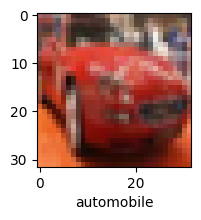

In [ ]:
plot_sample(X_train, y_train, 5)

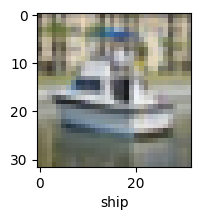

In [ ]:
plot_sample(X_train, y_train, 501)

In [ ]:
X_train = X_train /255.0
X_test = X_test / 255.0

In [ ]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32,32,3)),
    layers.Dense(3000, activation = 'relu'),
    layers.Dense(1000, activation = 'relu'),
    layers.Dense(10, activation = 'softmax')
])

ann.compile(optimizer = 'SGD',
            loss= 'sparse_categorical_crossentropy',
            metrics = ['accuracy'])

ann.fit(X_train, y_train, epochs = 5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 134s 85ms/step - accuracy: 0.3577 - loss: 1.8139
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.4268 - loss: 1.6231
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 122s 78ms/step - accuracy: 0.4530 - loss: 1.5452
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 83ms/step - accuracy: 0.4777 - loss: 1.4828
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 84ms/step - accuracy: 0.4941 - loss: 1.4355


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.32      0.44      1000
           1       0.75      0.41      0.53      1000
           2       0.49      0.14      0.22      1000
           3       0.36      0.29      0.32      1000
           4       0.36      0.46      0.40      1000
           5       0.50      0.22      0.30      1000
           6       0.55      0.50      0.52      1000
           7       0.29      0.84      0.43      1000
           8       0.56      0.68      0.61      1000
           9       0.53      0.60      0.56      1000

    accuracy                           0.45     10000
   macro avg       0.51      0.45      0.43     10000
weighted avg       0.51      0.45      0.43     10000



In [ ]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

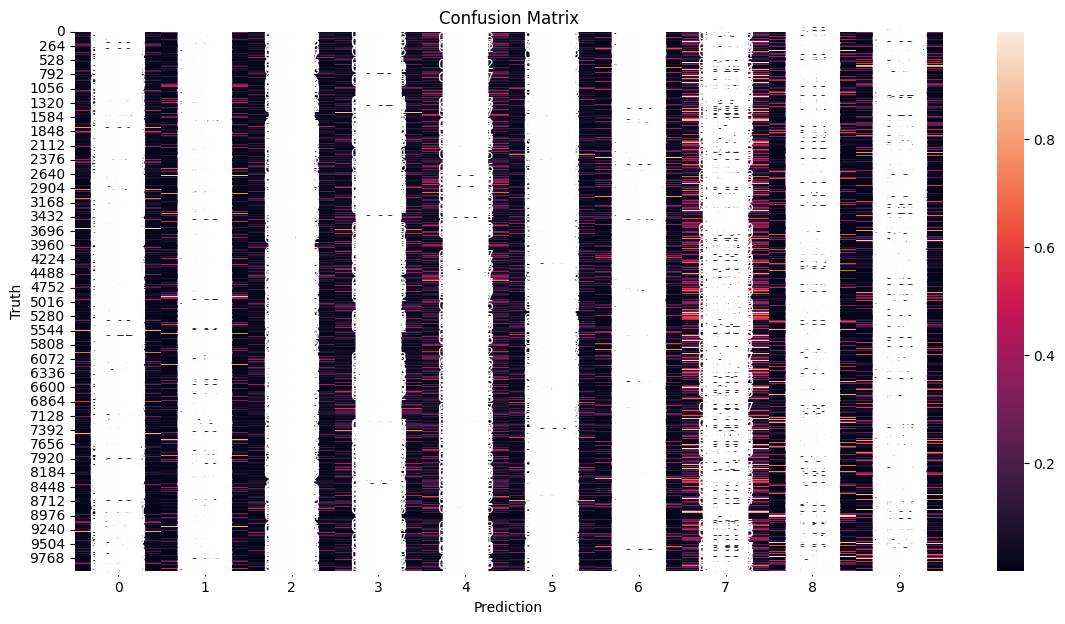

In [ ]:
plt.figure(figsize = (14,7))
sns.heatmap(y_pred, annot = True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters = 32, kernel_size = (3,3),
                  activation = 'relu', input_shape = (32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters = 64, kernel_size = (3,3),
                  activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 42ms/step - accuracy: 0.4710 - loss: 1.4644
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.6121 - loss: 1.1132
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.6598 - loss: 0.9766
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6898 - loss: 0.8938
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7123 - loss: 0.8322
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.7281 - loss: 0.7818
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7450 - loss: 0.7364
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7592 - loss: 0.6941
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.7710 - loss: 0.6581
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.7811 - loss: 0.6241


In [ ]:
cnn.evaluate(X_test, y_test)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

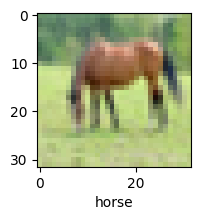

In [ ]:
plot_sample(X_test, y_test, 60)

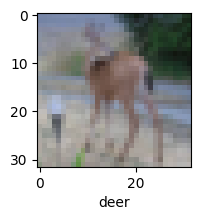

In [ ]:
plot_sample(X_test, y_test, 100)

In [ ]:
classes[y_classes[60]]

'horse'

In [ ]:
# Enhance CNN

from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data Augmentation ---
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# --- Enhanced CNN Model ---
new_cnn = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

new_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Train with augmented data
new_cnn.fit(datagen.flow(X_train, y_train, batch_size=64),
            epochs=20,
            validation_data=(X_test, y_test))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 444s 560ms/step - accuracy: 0.4280 - loss: 1.6869 - val_accuracy: 0.5205 - val_loss: 1.4568
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 436s 558ms/step - accuracy: 0.5786 - loss: 1.1833 - val_accuracy: 0.6486 - val_loss: 1.0019
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 442s 565ms/step - accuracy: 0.6331 - loss: 1.0337 - val_accuracy: 0.6300 - val_loss: 1.0710
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 441s 564ms/step - accuracy: 0.6697 - loss: 0.9458 - val_accuracy: 0.6977 - val_loss: 0.8761
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 436s 558ms/step - accuracy: 0.6910 - loss: 0.8807 - val_accuracy: 0.7185 - val_loss: 0.8349
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 443s 567ms/step - accuracy: 0.7095 - loss: 0.8402 - val_accuracy: 0.7513 - val_loss: 0.7224
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 438s 561ms/step - accuracy: 0.7205 - loss: 0.8027 - val_accuracy: 0.7386 - val_loss: 0.7787
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 437s 559ms/step - accuracy: 0.7333 -

=== Original CNN ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7026 - loss: 0.8944
=== Enhanced CNN ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8153 - loss: 0.5405
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step
              precision    recall  f1-score   support

    airplane       0.86      0.81      0.83      1000
  automobile       0.87      0.96      0.91      1000
        bird       0.81      0.66      0.73      1000
         cat       0.72      0.63      0.67      1000
        deer       0.81      0.77      0.79      1000
         dog       0.74      0.77      0.76      1000
        frog       0.71      0.95      0.81      1000
       horse       0.93      0.80      0.86      1000
        ship       0.91      0.88      0.89      1000
       truck       0.83      0.92      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



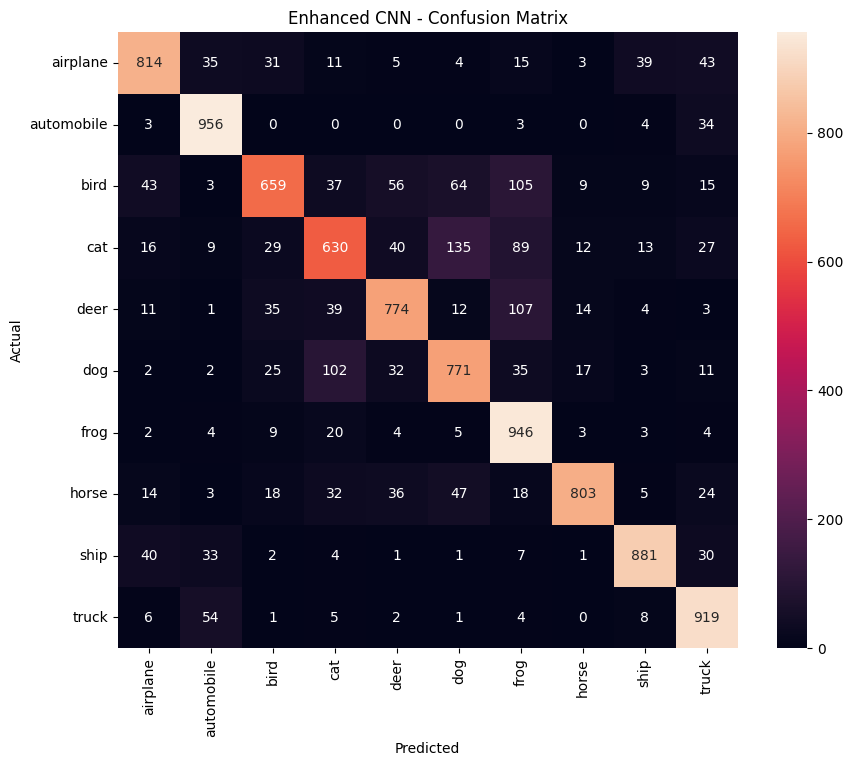

In [ ]:
# compare both old model CNN and enhanced CNN

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate both
print("=== Original CNN ===")
cnn.evaluate(X_test, y_test)

print("=== Enhanced CNN ===")
new_cnn.evaluate(X_test, y_test)

# Classification report for new_cnn
y_pred_new = new_cnn.predict(X_test)
y_pred_new_classes = [np.argmax(e) for e in y_pred_new]
print(classification_report(y_test, y_pred_new_classes, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_new_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Enhanced CNN - Confusion Matrix')
plt.show()

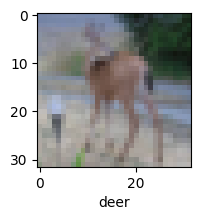

In [ ]:
plot_sample(X_test, y_test, 100)